### Figure 5

This code generates Figure 5 of the paper. This figure corresponds to analysis of A549 cells treated with 100nM dexamethasone <br>
<br>
INPUT:<br>
processed/ExpDecayConst_params.csv : Parameters for two-state model for each dataset<br>
processed/Compiled_accessible_target_ChIP_peaks.csv: Cumulative positional distribution of<br>
TF binding events
<br>
<br>
OUTPUT: <br>
Figure5B-C.pdf <br>




In [1]:
## Load required modules and functions
import os 
import pandas as pd
import numpy as np
from plotnine import *
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from math import exp,log
from scipy.stats import norm
from utils import *
import seaborn as sns
import patchworklib as pw
from random import choices
from statannot import add_stat_annotation
from sklearn.linear_model import LinearRegression
import math
from sklearn.metrics import *
from gprofiler import GProfiler

#Set fontsize and point size for figures
font_size = 44
point_size = 6

#Set working directory
working_dir ="TF_Positional_Distribution_Model/data/ENCODE/A549_Perturbation/ChIP-seq/"
os.chdir(working_dir)

<Figure size 72x72 with 0 Axes>

## Load model parameters and peak data

In [2]:
#Load compiled peak distribution and parameters for each fit
params= pd.read_csv('processed/ExpDecayConst_params.csv', index_col =0)
df= pd.read_csv('processed/Compiled_accessible_target_ChIP_peaks.csv', index_col =0)

#Merge parameters for each cell line
df = df.merge(params,on=['TF','Treatment'])

#Reference annotation file
TSS_ref = pd.read_table('../../TF_TSS_10kb_named.bed')
TSS_ref['TSS'] = TSS_ref.end - 10000

## Classification of target genes as true and spurious

In [3]:
#Initialize compiled gene classification
compiled_summary = pd.DataFrame()

#Loop through treatment and atac conditions
treatments = ['control','dexamethasone']

cutoffs_compiled= pd.DataFrame()


for idx, treatment in enumerate(treatments):
    tfs= os.listdir(treatment)
    for tf in tfs:
        if any(tf  == params.TF):
            #Load files
            df =  pd.read_table(treatment +'/'+tf + '/'+ treatment + '_consensuspeaks_accessible_'+treatment+'.bed',)
            df_named =  pd.read_table(treatment +'/'+tf + '/'+ treatment + '_consensuspeaks_accessible_'+treatment+'_named.bed',
                                     names = ['chrom','start','end','Gene' ])
            df = df.merge(df_named, on = ['chrom','start','end'])

            #Select rows with accessible peaks
            df['../../../ATAC-seq/'+treatment + '/' + treatment+'_consensuspeaks_sorted.bed'] == 1

            #select peaks with atleast 1 binding event
            tf_col = [i for i in df.columns if 'ENC' in i]
            df = df.loc[df[tf_col].sum(axis = 1) >0]         
            df = df.drop_duplicates()
            
            if df.shape[0] > 10:
                #Get distance of peak from TSS
                df=df.merge(TSS_ref[['TSS','Gene']])
                df['start_diff'] =  df['start'] - df['TSS']
                df['end_diff'] =  df['end'] - df['TSS']
                df['min_dist'] = df.apply(lambda x: abs(sum([x['start_diff'], x['end_diff']])/2), axis =1)

                #Extract params for condition
                params_sub = params.loc[(params.TF == tf) & (params.Treatment == treatment)]

                #Classify genes as true and spurious
                thresholds = [0.001,0.01,0.05,0.1, 0.2,0.3,0.4,0.5,0.7]
        
                threshold_cutoffs =  n_max_true(params_sub.rb.values[0],
                                                params_sub.tau.values[0],
                                                params_sub.rs.values[0], thresholds)
                for idx,val in threshold_cutoffs.iterrows():
                    df['Binding_' + str(thresholds[idx])] = df.min_dist <= val['Distance']

                #Compile threhsold cutoffs
                threshold_cutoffs['TF'] = tf
                threshold_cutoffs['Treatment'] = treatment
                cutoffs_compiled= pd.concat([threshold_cutoffs, cutoffs_compiled])


                binding_cols = [i for i in df.columns if 'Binding_' in i]
                #Select genes with true binding
                genes_summary = df.groupby('Gene').apply(lambda x: (x[binding_cols]==True).any())
                #Genes with all spurious binding
                genes_summary_sp = df.groupby('Gene').apply(lambda x: (x[binding_cols]==False).all())
                #Remove intermediate genes
                genes_summary =genes_summary.loc[(genes_summary.any(axis=1)) | (genes_summary_sp.all(axis=1)) ]


                genes_summary['TF'] = tf
                genes_summary['Treatment'] = treatment


                #Compile across datasets
                compiled_summary = pd.concat([compiled_summary,genes_summary])


compiled_summary.to_csv('processed/CompiledGeneClassification_multipleThresholds.csv')

In [4]:
## Reformat and pivot data
compiled_threshold = pd.DataFrame()
for threshold in compiled_summary.columns[1:-2]:
    compiled = compiled_summary.reset_index().pivot(index=['Gene','TF'], columns='Treatment', values= threshold).reset_index().drop_duplicates()
    compiled['Threshold'] = threshold.split('_')[1]
    compiled_threshold = pd.concat([compiled_threshold, compiled])

## Load and process RNA-seq data

In [5]:
## Get RNA counts (From original analysis)
rna = pd.read_csv('../RNA-seq/processed/A549_dex12h_RNAseq_counts.csv', index_col = 0)

## Calculate Log2FC
control_cols = [i for i in rna.columns if 'control' in i]
dex_cols = [i for i in rna.columns if 'dexamethasone' in i]
rna['log2FC'] = np.log2((rna[dex_cols].mean(axis=1) +1) /(rna[control_cols].mean(axis=1) +1))

## Assign labels to each gene 

In [6]:
compiled_threshold['Class'] = "Expected/Predicted"
compiled_threshold['Class'].loc[compiled_threshold.control == compiled_threshold.dexamethasone] = "NotExpected/NotPredicted"

compiled_threshold['Class'].loc[((compiled_threshold.control.isna())& (compiled_threshold.dexamethasone == False))|
                                ((compiled_threshold.dexamethasone.isna())& (compiled_threshold.control== False))] = "Expected/NotPredicted"

compiled_threshold['Class'].loc[((compiled_threshold.control == True) & (compiled_threshold.dexamethasone == False))|
                                ((compiled_threshold.dexamethasone == True) & (compiled_threshold.control == False))] = "NotExpected/Predicted"


## Identify Not expected/Not predicted genes across all TFs
NENF = compiled_threshold.groupby(['Gene']).apply(lambda x: x if all(x.Class =='NotExpected/NotPredicted') else None)
NENF_Gene = NENF.Gene.unique()

#Genes with exp data but no binding

rna_genes = rna.loc[~rna.index.isin(compiled_threshold.Gene)].index
NENF_Gene = list(NENF_Gene)+ list(rna_genes)

## Plot Figure 5B and 5C

In [8]:
font_size = 40
ax =[]
col = sns.color_palette("colorblind",4).as_hex()

#Test effect on group size for varying thresholds
compiled_rna_threshold = pd.DataFrame()
#for threshold in compiled_threshold.Threshold.unique():

threshold ='0.1'
fig5B = []
compiled = compiled_threshold.loc[compiled_threshold.Threshold == threshold]
#Get Expected/Not Predicted genes for threshold
ENF = compiled[['Gene','Class']].groupby(['Gene']).apply(lambda x:all(x.Class =='Expected/NotPredicted')).reset_index(name="Expected/NotPredicted")
ENF_Gene = ENF.loc[ENF['Expected/NotPredicted']].Gene.unique()


for idx,tf in enumerate(['BCL3', 'JUN', 'CTCF']):    
    
        compiled = compiled_threshold.loc[compiled_threshold.Threshold == threshold]
        compiled = compiled.loc[compiled.TF==tf]
        compiled = compiled.loc[compiled.Class.isin(['Expected/Predicted','NotExpected/Predicted' ])]
        genes_all = compiled.Gene.unique()

        #Subset mRNA expression for target genes
        rna_sub = rna.loc[rna.index.isin(genes_all)]
        rna_sub['Gene'] = rna_sub.index
        compiled_rna = rna_sub.merge(compiled[['Gene','Class']], on = 'Gene', how = 'left')

        #Add NENF/ENF genes
        rna_NENF = rna.loc[rna.index.isin(NENF_Gene)]
        rna_NENF['Class'] = "NotExpected/NotPredicted"
        rna_NENF['Gene'] = rna_NENF.index
        rna_ENF = rna.loc[rna.index.isin(ENF_Gene)]
        rna_ENF['Class'] = "Expected/NotPredicted"
        rna_ENF['Gene'] = rna_ENF.index

        #compile all classes
        compiled_rna = pd.concat([compiled_rna,rna_NENF])
        compiled_rna = pd.concat([compiled_rna,rna_ENF])
        
        
        #Compile data for each threshold
        compiled_rna.Class = pd.Categorical(compiled_rna.Class , 
                                             ['NotExpected/NotPredicted','Expected/NotPredicted',
                                              'Expected/Predicted', 'NotExpected/Predicted'])
        labels = ['NotExpected/NotPredicted','Expected/NotPredicted',
                                              'Expected/Predicted', 'NotExpected/Predicted']
        compiled_rna['log2FC (abs)'] = np.abs(compiled_rna['log2FC'])


        #compile all RNA data
        compiled_rna['Threshold'] = threshold
        compiled_rna_threshold = pd.concat([compiled_rna_threshold,compiled_rna])
    
        #Plot Figure 5B for threshold of 0.05 (threshold for identifying 95% biologically relevant binding events
        #if threshold == '0.05':

        compiled_rna = compiled_rna.loc[compiled_rna.Class.isin(labels)]
        compiled_rna.Class =[i.replace("/","\n"  ) for i in compiled_rna.Class]
        compiled_rna.Class = pd.Categorical(compiled_rna.Class , 
                                         ['NotExpected\nNotPredicted','Expected\nNotPredicted',
                                          'Expected\nPredicted', 'NotExpected\nPredicted'])
        labels =[i.replace("/","\n"  ) for i in labels]

        #PLOT
        fig5B.append(pw.Brick(figsize=(10,10)))

        sns.violinplot(data=compiled_rna,x= 'Class',y = 'log2FC (abs)',
                       ax=fig5B[idx],fontsize =font_size, palette =col)

        fig5B[idx].set(
            xlabel='\n', 
            ylabel='|$log_{2}FC$|\n',
            title = tf
        )

        fig5B[idx].tick_params(labelsize=font_size)
        fig5B[idx].tick_params(axis='x', labelrotation=45)
        fig5B[idx].set_ylabel(fig5B[idx].get_ylabel(),fontsize = font_size)
        fig5B[idx].set_title(fig5B[idx].get_title(),fontsize = font_size)
        fig5B[idx].spines[['left','bottom']].set_linewidth(2) 
        fig5B[idx].spines[['top','right']].set_linewidth(0) 

        #Add sample size
        x_labels_n = compiled_rna.groupby('Class').size().reset_index(name = 'Size')
        x_labels_n['NewLabel'] = x_labels_n['Class'].astype(str)+ '\n(n = ' + x_labels_n['Size'].astype(str) + ')'
        fig5B[idx].set_xticklabels(x_labels_n['NewLabel'])


        fig5B[idx], test_results = add_stat_annotation(fig5B[idx],data=compiled_rna.loc[compiled_rna.Class.isin(labels)],
                                                x= 'Class',y = 'log2FC (abs)',
                                           box_pairs=[(labels[0], labels[1]), 
                                                     (labels[0], labels[3]),
                                                     (labels[2], labels[1]),
                                                     (labels[2], labels[3]),
                                                     (labels[1], labels[3])],
                                           line_offset_to_box=0.1, line_offset=0.05, 
                                            fontsize=font_size,line_height=0.0, text_offset=0,
                                          test='Mann-Whitney', 
                                      pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"], [1e-2, "**"], [0.05, "*"]],
                                      loc='inside', verbose=2)

p-value annotation legend:
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

NotExpected
NotPredicted v.s. Expected
NotPredicted: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.610e-18 U_stat=7.817e+07
Expected
NotPredicted v.s. Expected
Predicted: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=0.000e+00 U_stat=4.371e+06
Expected
Predicted v.s. NotExpected
Predicted: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.029e-04 U_stat=8.432e+05
Expected
NotPredicted v.s. NotExpected
Predicted: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=2.038e-192 U_stat=8.748e+05
NotExpected
NotPredicted v.s. NotExpected
Predicted: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=2.519e-247 U_stat=1.997e+06
p-value annotation legend:
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <

<Figure size 432x288 with 0 Axes>

## GO analysis

In [9]:
tf = 'BCL3'
threshold = '0.1'
compiled = compiled_threshold.loc[(compiled_threshold.Threshold == threshold) &
                                 (compiled_threshold.TF == tf)]
genes_all = compiled.Gene.unique()

#Get expected and predicted genes
genes_predicted = compiled.loc[(compiled.Threshold =='0.1') &
                           (compiled['Class'].isin(['Expected/Predicted',
                                                    'NotExpected/Predicted']))]

genes_expected = compiled.loc[(compiled.Threshold =='0.1') &
                              (compiled['Class'].isin(['Expected/Predicted',
                                                      'Expected/NotPredicted']))]
genes_expected = list(genes_expected.Gene.unique()) +list( ENF_Gene[1:])
#run gProfiler
#Get biological processes associated with expected and predicted genes 
gp = GProfiler(return_dataframe=True)
profile_predicted = gp.profile(organism='hsapiens',
                               sources = ['GO:BP'],
                              user_threshold=0.00001,
                               query= list(genes_predicted.Gene.unique()),
                              no_evidences=False)

profile_expected = gp.profile(organism='hsapiens',
                              sources = ['GO:BP'],
                              user_threshold=0.00001,
                              query=genes_expected,
                              no_evidences=False)




#Compile term sizes and list of terms
profile_predicted['TF'] = tf
profile_predicted['Sample'] = 'Predicted'
profile_expected['TF'] = tf
profile_expected['Sample'] = 'Expected'


In [10]:
profile_predicted_terms = profile_predicted.loc[[('DNA'  in i )| ('cell cycle'  in i ) for i in profile_predicted.name]]
fig5C = (ggplot(profile_predicted_terms)
+geom_point(aes(x='intersection_size/term_size', y = 'name',fill = '-np.log10(p_value)'), size = 15)
+theme_bw()
+ labs(fill = '$-log_{10}(p)$\n' )
+xlab('Gene ratio')
+ylab('')
+scale_fill_continuous(limits = (5,15))
+theme(
    text = element_text(size = font_size), 
    axis_title_x = element_text(size = font_size + 10),  
    axis_text_x = element_text(size = font_size + 10),  
    legend_title = element_text(size = font_size + 10),  
    legend_text = element_text(size = font_size+10),   
    legend_key_size =70                 
  )

)



fig5C =  pw.load_ggplot(fig5C, figsize=(10,10))




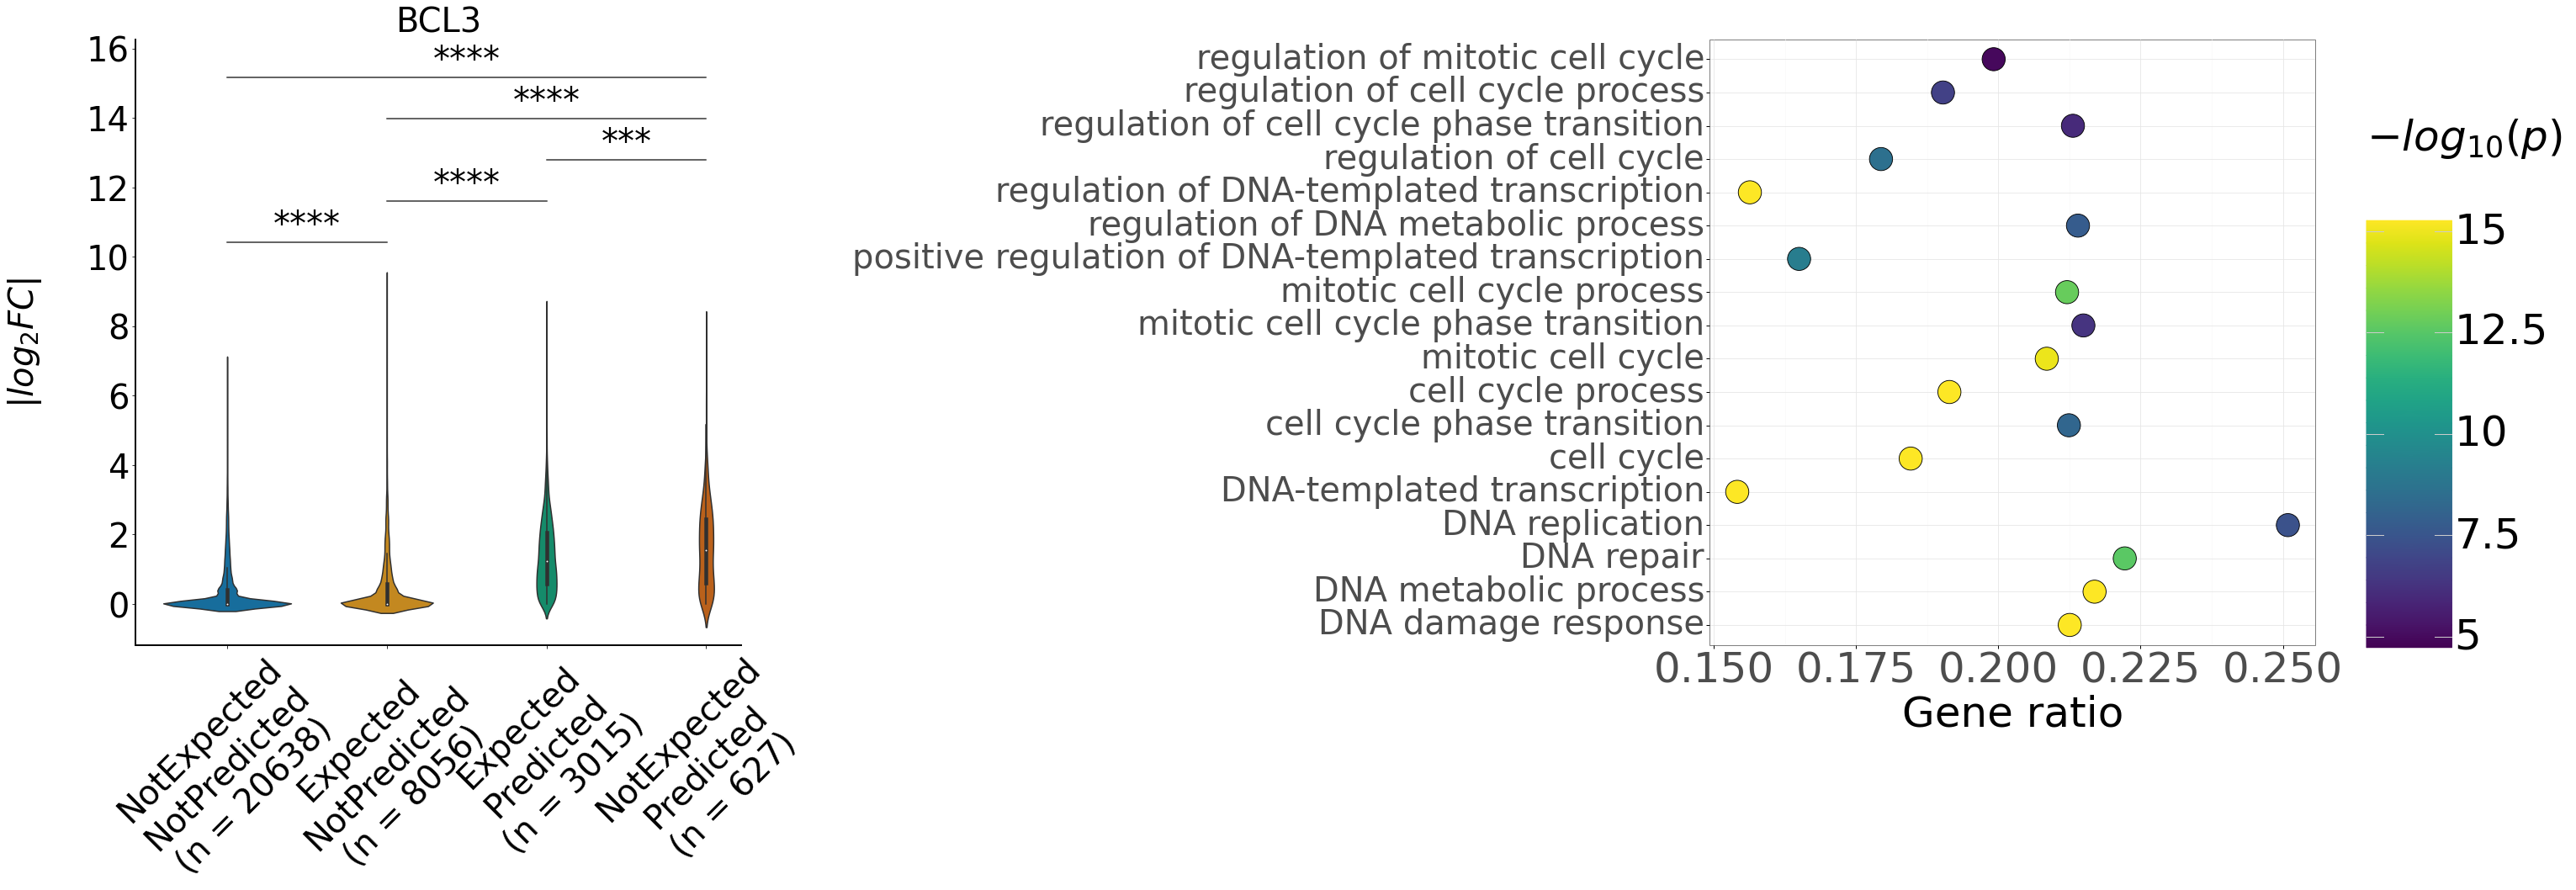

In [11]:
fig5 = fig5B[0] + fig5C
fig5.savefig('../../../../Figures/Figure5.pdf')

## Suplementary figure 10

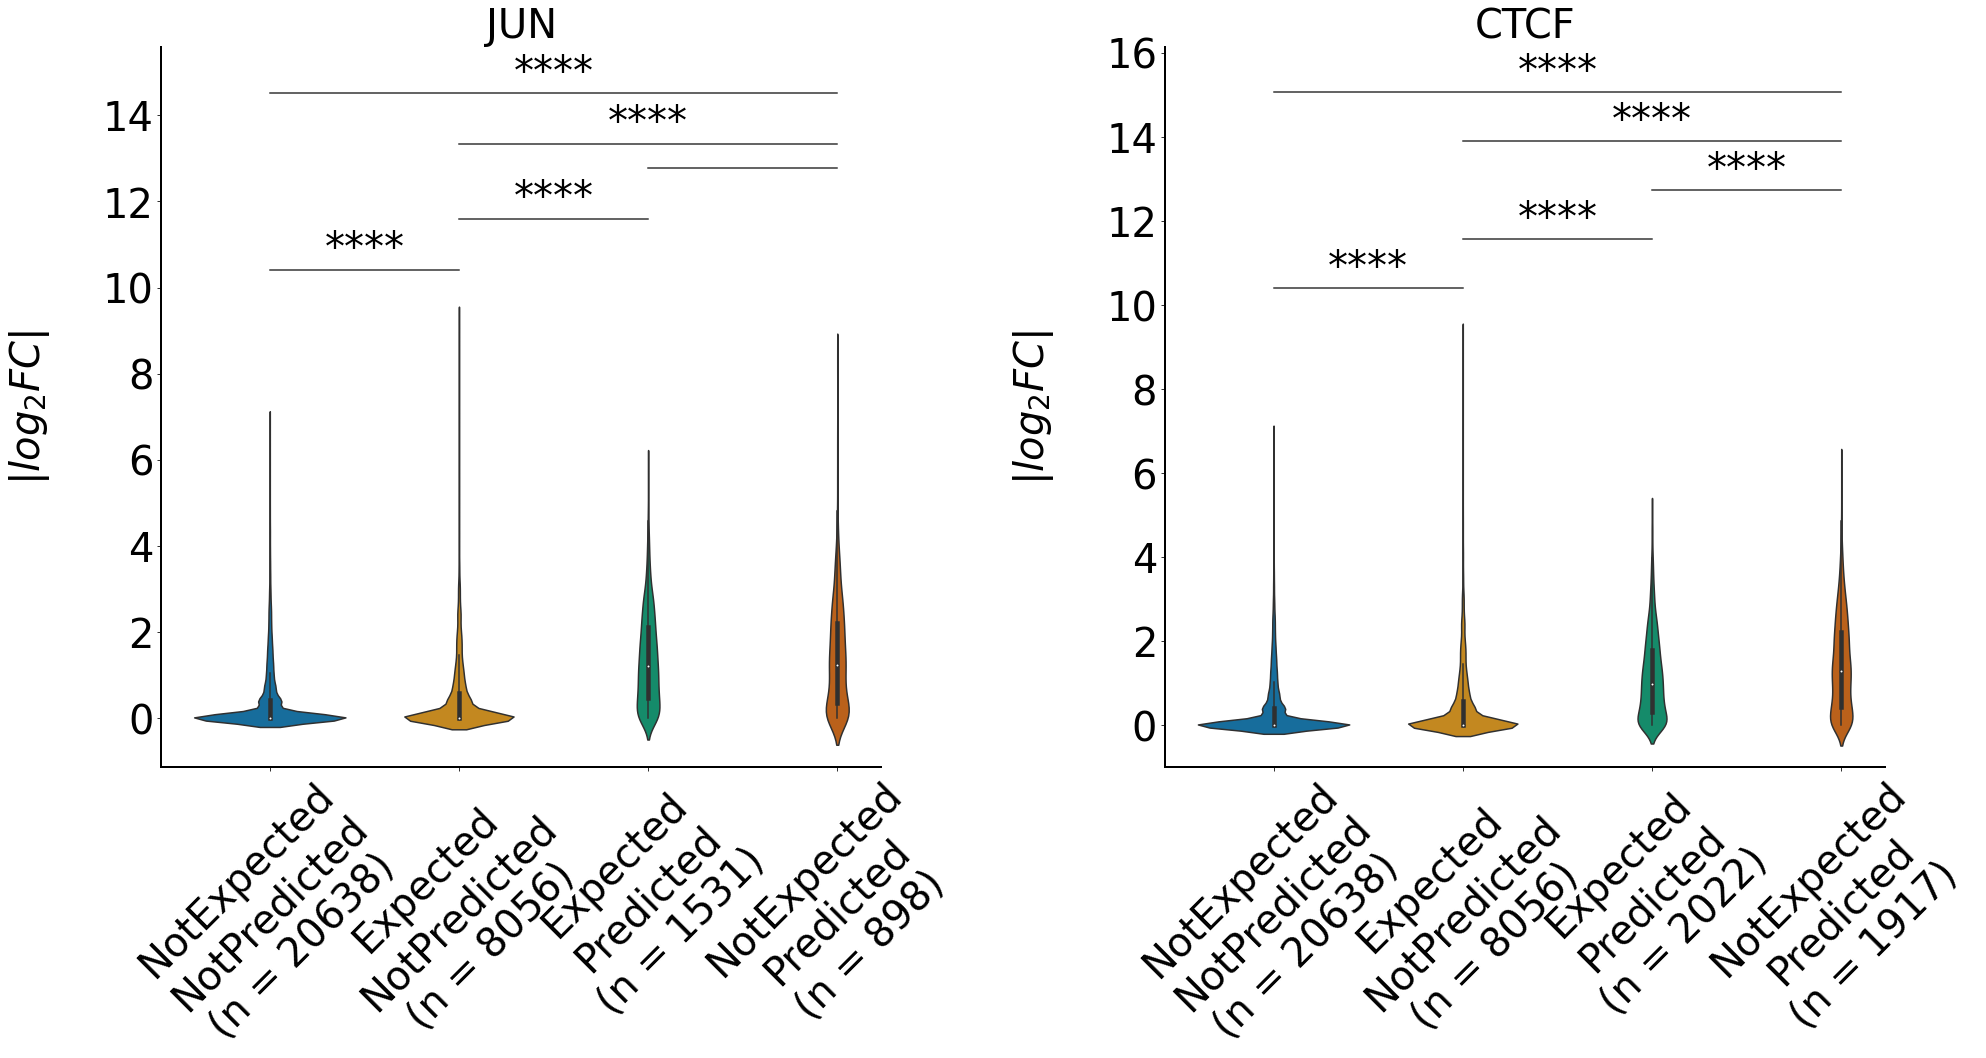

In [12]:
figS10= fig5B[1] +  fig5B[2] 
figS10.savefig('../../../../Figures/SFig10.pdf')

## Supplementary Figure 11

In [13]:
compiled_profiles = pd.DataFrame()

#Subset interactions for threshold
compiled_5 = compiled_threshold.loc[compiled_threshold.Threshold == '0.1']
#Get Expected/Not Predicted genes for threshold
ENF = compiled_5.groupby(['Gene']).apply(lambda x: x if all(x.Class =='Expected/NotPredicted') else None)
ENF_Gene = ENF.Gene.unique()

for tf in compiled_5.TF.unique():     
    compiled = compiled_5.loc[compiled_5.TF==tf]
    genes_all = compiled.Gene.unique()
    
    #Get expected and predicted genes
    genes_predicted = compiled.loc[(compiled.Threshold =='0.1') &
                               (compiled['Class'].isin(['Expected/Predicted',
                                                        'NotExpected/Predicted']))]

    genes_expected = compiled.loc[(compiled.Threshold =='0.1') &
                                  (compiled['Class'].isin(['Expected/Predicted',
                                                          'Expected/NotPredicted']))]
    genes_expected = list(genes_expected.Gene.unique()) +list( ENF_Gene[1:])
    #run gProfiler
    #Get biological processes associated with expected and predicted genes 
    gp = GProfiler(return_dataframe=True)
    profile_predicted = gp.profile(organism='hsapiens',
                                   sources = ['GO:BP'],
                              user_threshold=0.05,
                                   query= list(genes_predicted.Gene.unique()),
                                  no_evidences=False)
    
    profile_expected = gp.profile(organism='hsapiens',
                                  sources = ['GO:BP'],
                              user_threshold=0.05,
                                  query=genes_expected,
                                  no_evidences=False)




    #Compile term sizes and list of terms
    profile_predicted['TF'] = tf
    profile_predicted['Sample'] = 'Predicted'
    profile_expected['TF'] = tf
    profile_expected['Sample'] = 'Expected'
    
    compiled_profiles = pd.concat([compiled_profiles,
                                   profile_predicted[['name','term_size','p_value','intersection_size','TF','Sample']]])
    compiled_profiles = pd.concat([compiled_profiles,
                                   profile_expected[['name','term_size','p_value','intersection_size','TF','Sample']]])
                               
                                   
                                   
figS11= (ggplot(compiled_profiles.loc[compiled_profiles.TF.isin(['CTCF','BCL3','JUN'])])
+geom_boxplot(aes(x='TF', y = '-np.log10(p_value)',fill = 'Sample'), size =1.5)
#+geom_point(aes(x='TF', y = '-np.log10(p_value)',fill = 'Sample'))
+scale_fill_manual(values = ['#FA7162','#FFB60B'])
+theme_classic()
+theme(text=element_text(size=font_size))
+ylab('$-log_{10}(p)$')
+xlab('TF')
)

figS11  =  pw.load_ggplot(figS11, figsize=(20,16))



                

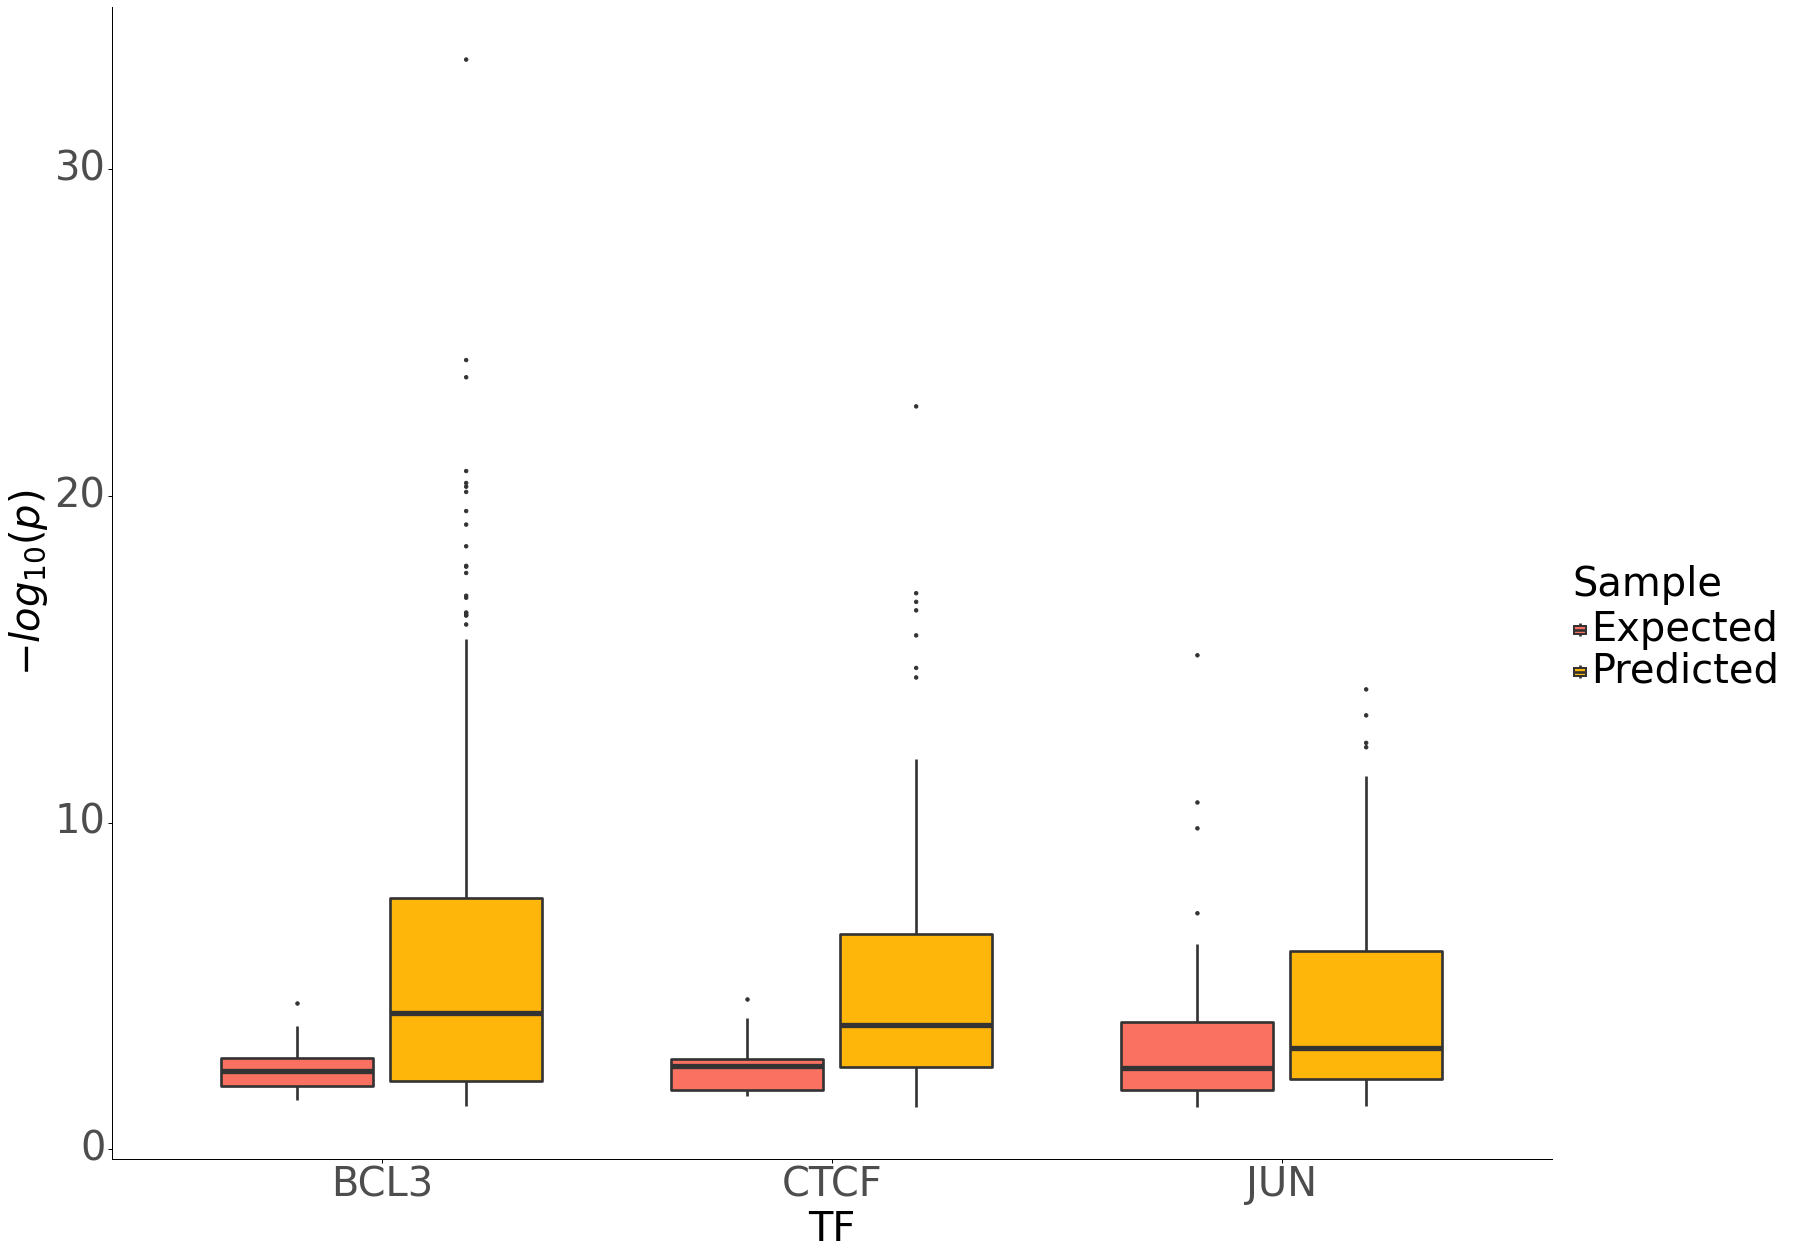

In [14]:
figS11.savefig('../../../../Figures/SFig11.pdf')

## Identifying reccurent genes

In [15]:
tf = 'BCL3'
threshold = '0.1'
compiled = compiled_threshold.loc[(compiled_threshold.Threshold == threshold) &
                                 (compiled_threshold.TF == tf)]
genes_all = compiled.Gene.unique()

#Get expected and predicted genes
genes_predicted = compiled.loc[(compiled.Threshold =='0.1') &
                           (compiled['Class'].isin(['Expected/Predicted',
                                                    'NotExpected/Predicted']))]

#Get biological processes associated with expected and predicted genes 
gp = GProfiler(return_dataframe=True)
profile_predicted = gp.profile(organism='hsapiens',
                               sources = ['GO:BP'],
                              user_threshold=0.00001,
                               query= list(genes_predicted.Gene.unique()),
                              no_evidences=False)



In [16]:
from collections import Counter
compiled_occurence = pd.DataFrame()
p_range = [10**(-1*i) for i in range(5,20)]

for p in p_range:

    #Get subset of profiles with p threshold
    profile_predicted_sub = profile_predicted.loc[profile_predicted.p_value < p]
    
    cl =  'NotExpected/Predicted'
    
    #Get genes predicted
    genes_class = compiled.loc[(compiled.Threshold =='0.1') & 
                                            (compiled['Class'].isin([cl]))].Gene
    genes = [j for i in profile_predicted_sub.intersections for j in i if j not in genes_class]
    n = profile_predicted_sub.shape[0]
    c = Counter(genes)
    df = pd.DataFrame.from_dict(c,orient='index').reset_index()
    df.columns = ['Gene','Occurence']
    df['Occurence'] = df['Occurence']/n
    df['Category'] = cl
    df['p'] = p
    compiled_occurence = pd.concat([compiled_occurence, df])

In [17]:
genes= compiled_occurence.Gene.loc[compiled_occurence.Occurence > 0.75].unique()
','.join(genes)

'AKT1,ATM,KAT5,PARK7,TGFB1,ABL1,CHEK2,PKD1,SIRT6,SQSTM1,ZMPSTE24,ARID1A,ARID1B,ATF2,CLOCK,LRP5,MAPK14,RB1,SMARCA4,SMARCC2,SMARCD2,SMARCE1,USP16,BLM,MDC1,MEN1,MTA1,NIPBL,PHIP,PSRC1,SETD2,AMBRA1,BARD1,DPF2,E2F1,HINFP,PCNA,PIAS4,SRC,SUMO1,UFL1,XRCC6,CCNA2,RNF168,SKP2,FBXO4,HDAC6,MAGEF1,MTOR,PSMD10,CRY1,DDX11,DOT1L,DYRK1A,DYRK1B,GTF2H1,ING4,MAP2K1,POGZ,SFN,TOP2A,USP47,ZBED3,ACTR5,BIRC2,CCNK,CDK5,CYP1B1,DHX36,FZR1,GCLC,INO80E,NCK2,NFE2L2,NFRKB,OGG1,PARP3,PRKCQ,SETD7,TRIM13,USP13,UVRAG,BAG4,BAG6,BAP1,BCL6,BIRC5,BRCC3,CDC14B,CDC7,CDK8,CHP1,CSNK2A2,CTBP1,DVL3,EIF2AK2,ERCC8,FANCM,GNL3L,IMPACT,MAPKAPK2,MBIP,MLST8,MYOCD,PELI1,PER2,PINK1,PKIB,PPP2CB,PPP2R5B,PRKAR1A,PRKCI,PRMT1,PRR5L,PTK2B,RIOK2,RNF126,SETD3,SRPK1,STAT2,TET2,TET3,WDR5,ADNP,BCL10,BMI1,C14orf166,CAMK1,CCNT1,DGKQ,EFNA1,FGFR4,FOXF2,HINT1,HNRNPD,HTATIP2,HYAL2,IL11,IL18,KMT2A,MED30,MED8,NAA15,NDFIP1,NELFA,NELFE,NFATC2IP,NSD1,RAP2C,RNF40,RPS6KA5,RQCD1,SLCO3A1,TCF25,TCF7L2,TNIP1,TRIM24,TRIM26,UBE2E1,USP21,YES1,ZMIZ2,ABI1,AGTPBP1,AKTIP,ALS2